<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"> <h2 style="color: black; margin: 0px;"> Testing of presence of unphysical precip values in UKCP Local </h2>
    
In: UKCP Local: bias-corrected, 5km data
</div>

In [1]:
import numpy as np
import pandas as pd
import re
import time
import gc
import os
import sys
import math
import glob
import datetime
import geopandas as gpd
from shapely.geometry import MultiPolygon
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import Counter

from functions import *
from functions_stage2 import (get_rainfall_cube_subsection,get_rainfall_cube_subsection_notbc, setup_worker_logger, 
                              find_max_precip_location_new, find_temporal_profile_new, maybe_diagnose, analyse_peak_event,
                             plot_cluster_check, plot_n_peaks, get_exceedance_summary, plot_surrounding_ts, 
                              plot_surrounding_ts_new, find_problematic_catchment_em_combos)

# ── Config ────────────────────────────────────────────────────────────────────
from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 

# ── Define which catchments to run ────────────────────────────────────────────────────────────────────
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h2 style="color: black; margin: 0px;"> Find catchment, ensemble member combinations with values >150mm/hr </h2>

For each catchment - ensemble member combination, find the number of events exceeding the 150mm/hr threshold, and calculate this as a proportion of the total number of events.
</div>

In [2]:
results_df, problematic_catchment_names, problematic_catchment_nums = find_problematic_catchment_em_combos(all_catchments, CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, RAINFALL_CSV_DIR)
results_df

,Catchment No.,Catchment Name,Ensemble Member,Highest Peak (mm),Events > 150mm,Total Events,% Problematic
0,104,KintyreGroup,04,882.25,28,254,11.0
1,104,KintyreGroup,05,271.46,13,274,4.7
2,104,KintyreGroup,07,176.23,1,134,0.7
3,104,KintyreGroup,08,271.07,7,226,3.1
4,104,KintyreGroup,09,339.05,8,136,5.9
...,...,...,...,...,...,...,...
61,96,Navergroup,04,156.65,2,94,2.1
62,96,Navergroup,07,7916.53,60,169,35.5
63,96,Navergroup,09,2732.17,13,73,17.8
64,96,Navergroup,15,271.81,10,119,8.4


<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h2 style="color: black; margin: 0px;"> Plot location of catchments with problematic peaks </h2>

Colour catchments how many EMs have problems
</div>

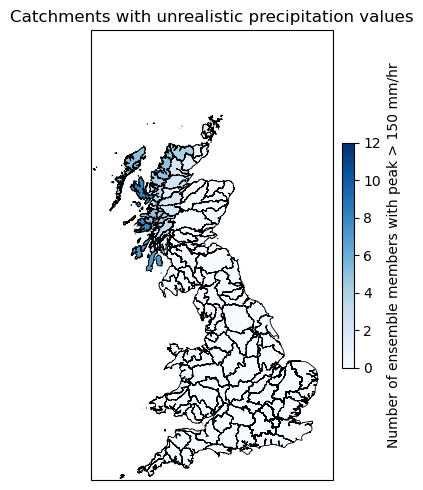

In [3]:
# Count how many ensemble members are problematic per catchment
ens_counts = Counter(problematic_catchment_nums)  # {catchment_num: count}

# Colourmap setup
max_count = len(ENSEMBLE_MEMBERS)
cmap      = cm.Blues
norm      = mcolors.Normalize(vmin=0, vmax=max_count)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': ccrs.OSGB()})

for catchment_num in CATCHMENTS['HA_NUM'].unique():
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    count          = ens_counts.get(catchment_num, 0)  # 0 if not problematic
    facecolor      = cmap(norm(count))
    ax.add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(), 
                      facecolor=facecolor, edgecolor='black', linewidth=0.6)

# Add colourbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Number of ensemble members with peak > 150 mm/hr', 
             shrink=0.5, pad=0.02)

ax.set_title('Catchments with unrealistic precipitation values')
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h2 style="color: black; margin: 0px;"> Testing results for one catchment: Catchment 96 (Naver Group) </h2>

Two test plots:  
1. A spatial plot of the catchment for each of 9 events which for this catchment/EM combination had unphysical values
    - This suggests that it’s not always the same grid cell affected in different instances of the unphysical values (although some grid cells do seem to be over represented)
2. Plot containing both (i) Plotted timeseries including the timesteps before and after the unphysical value in the grid cell in which it happened; and (ii) Spatial plot of values across the whole catchment for the 5 timesteps both before and after the unphysical value.
    - This suggests that it is mostly just an isolated occurrence in one time step, and one grid cell. 
    
Plot the same plots using data that hasn't been bias corrected:  
- This suggests that the problem is introduced by the bias correction. No unphysical values are present in the non-bias corrected data at the times and locations where they appear in bias-corrected data.
</div>

In [16]:
catchment_num = '96' #'94'
ens_num = '09'
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
catchment_name

'Navergroup'

In [17]:
rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

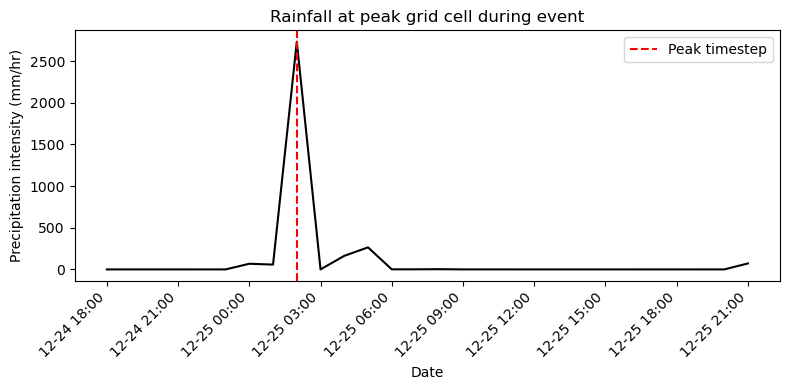


--- Exceedance summary (±10 timesteps around peak) ---
  Timesteps with ≥1 cell > 150mm : 3
  Cells exceeding in ≥1 timestep : 1
  Total (t, cell) exceedances    : 3
  Max cells in a single timestep : 1
  Cells-per-timestep breakdown   : [0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0]


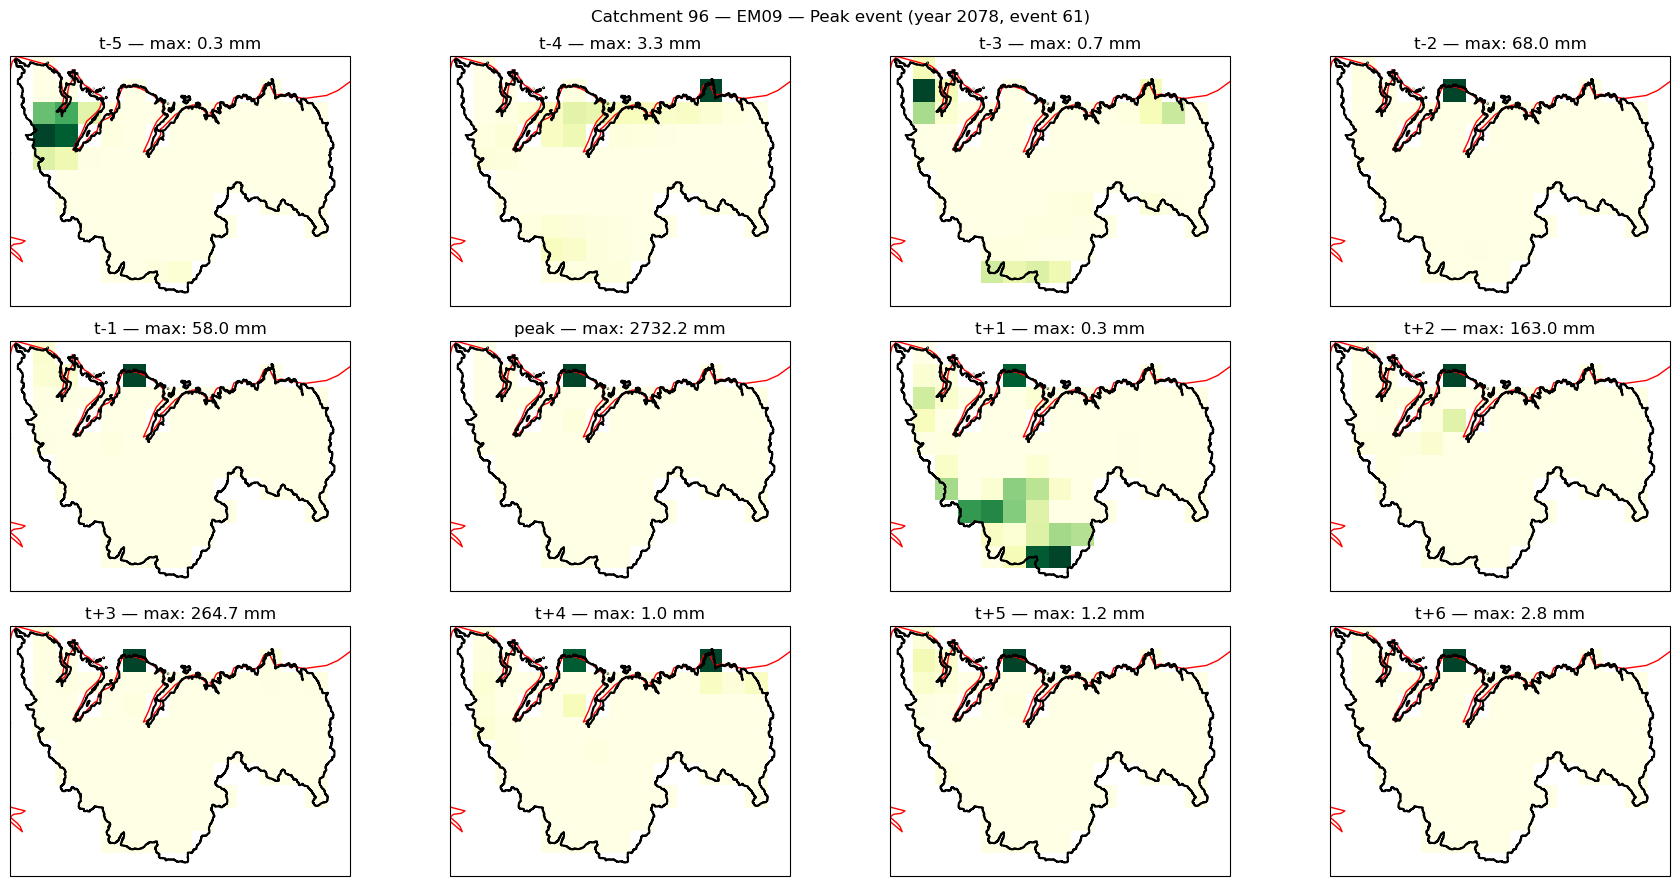

In [6]:
plot_surrounding_ts_new(rainfall_cube_dir_bc, catchment_num, ens_num, bc=True)

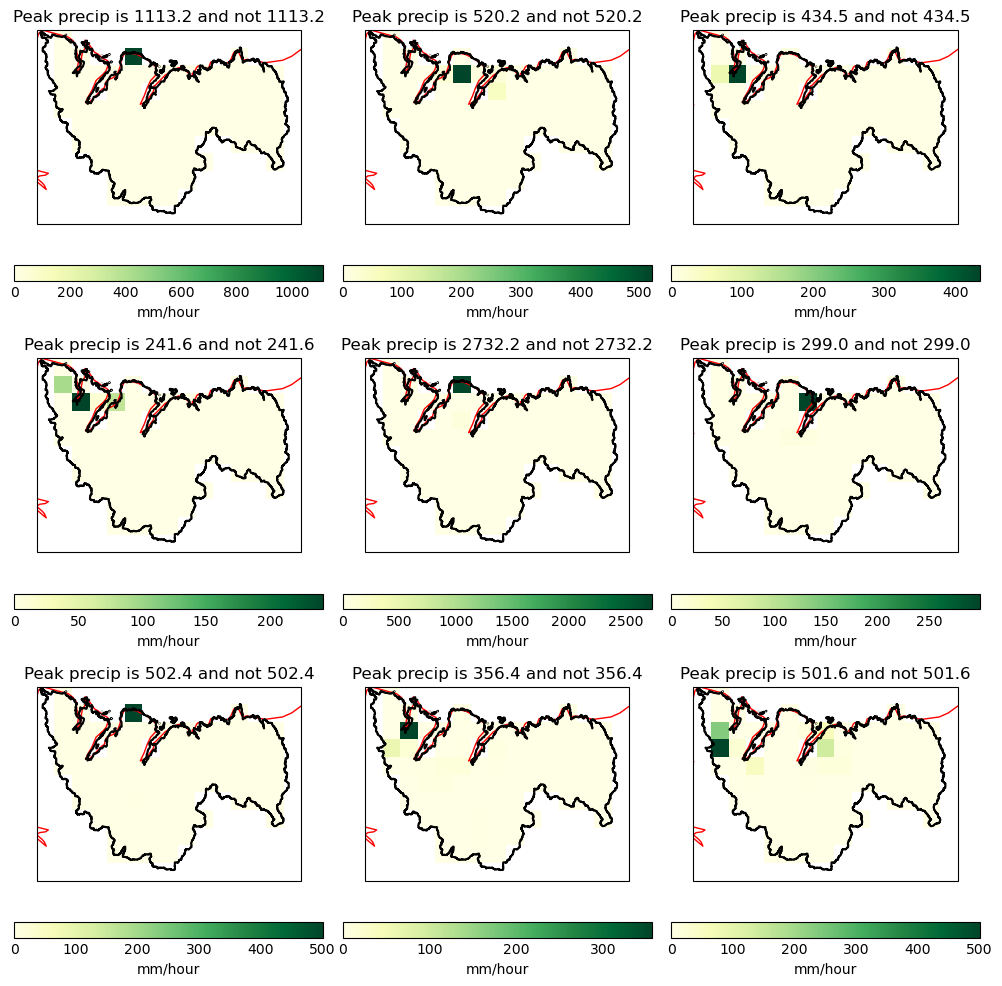

In [21]:
plot_n_peaks(rainfall_cube_dir_bc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=True)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
What happens if plot same plot using data that hasn't been bias corrected? 

</div>

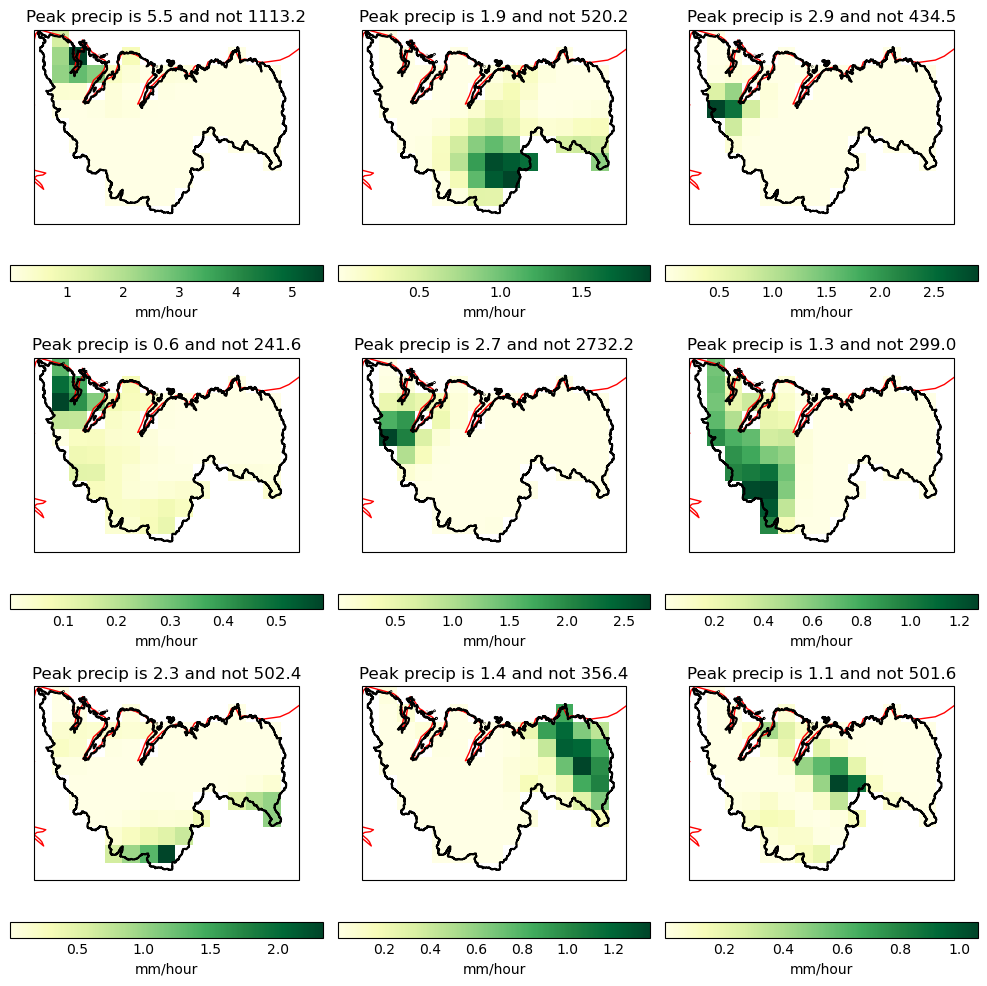

In [20]:
plot_n_peaks(rainfall_cube_dir_notbc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=False)

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h2 style="color: black; margin: 0px;"> Testing results for one catchment: Catchment 95 (Laxford Group) </h2>

Two test plots:  
1. A spatial plot of the catchment for each of 9 events which for this catchment/EM combination had unphysical values
    - This suggests that it’s not always the same grid cell affected in different instances of the unphysical values (although some grid cells do seem to be over represented)
2. Plot containing both (i) Plotted timeseries including the timesteps before and after the unphysical value in the grid cell in which it happened; and (ii) Spatial plot of values across the whole catchment for the 5 timesteps both before and after the unphysical value.
    - This suggests that it is mostly just an isolated occurrence in one time step, and one grid cell. 
    
</div>

In [22]:
catchment_num = '95' #'94'
ens_num = '07'
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
print(catchment_name)

rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

LaxfordGroup


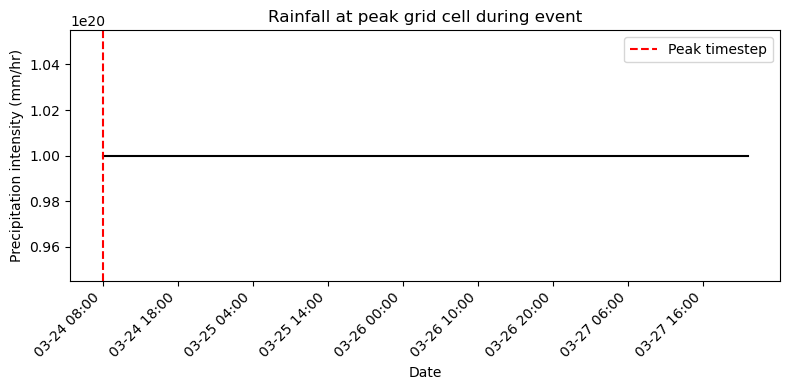


--- Exceedance summary (±10 timesteps around peak) ---
  Timesteps with ≥1 cell > 150mm : 11
  Cells exceeding in ≥1 timestep : 1
  Total (t, cell) exceedances    : 11
  Max cells in a single timestep : 1
  Cells-per-timestep breakdown   : [1 1 1 1 1 1 1 1 1 1 1]


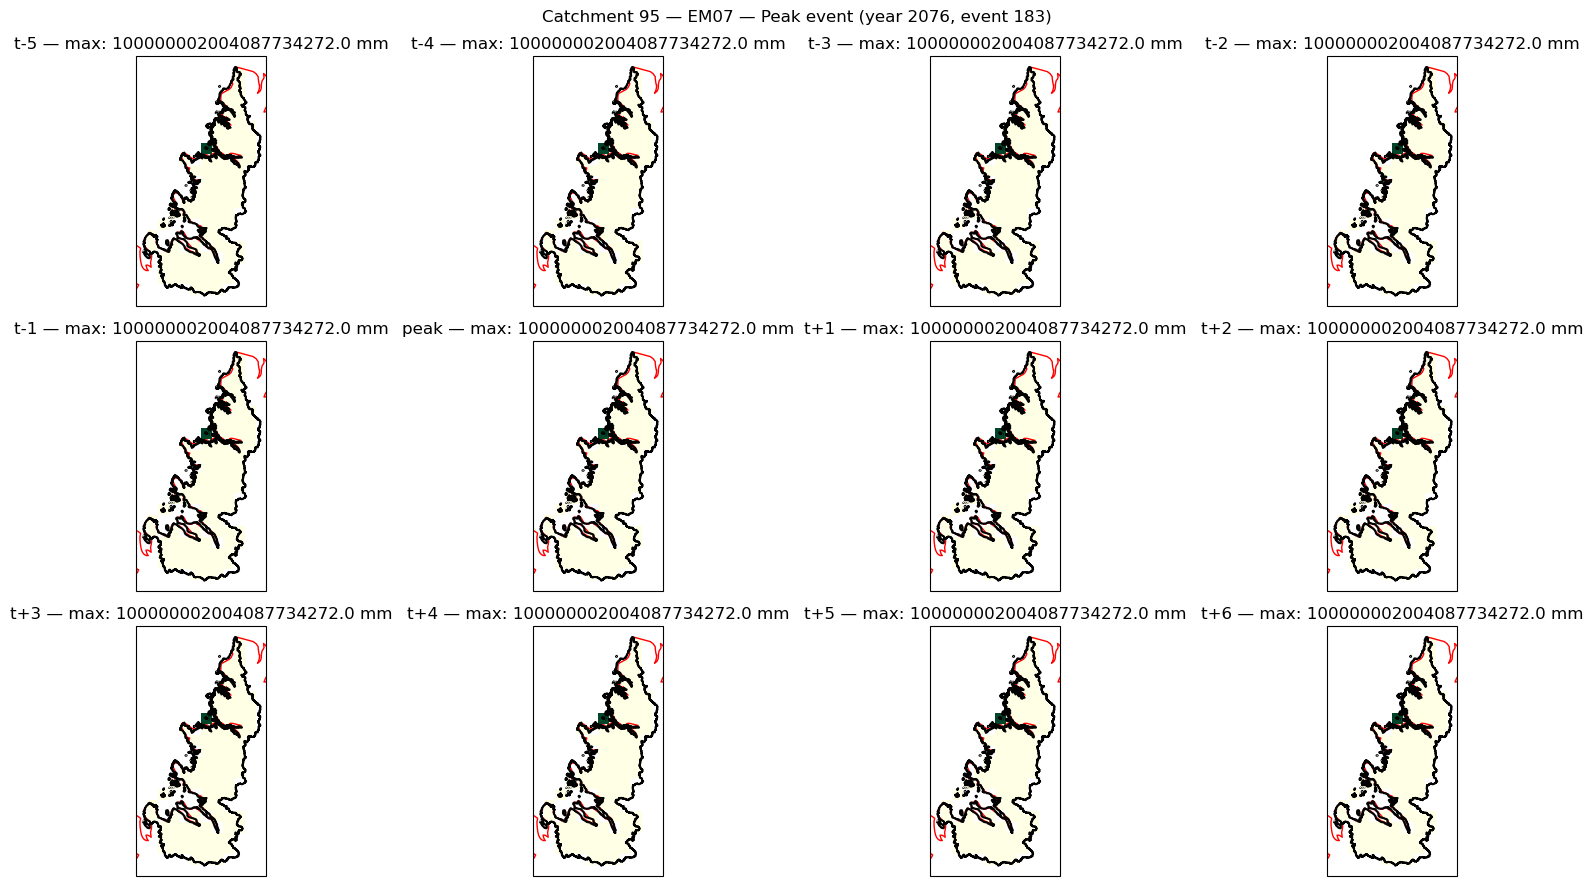

In [23]:
plot_surrounding_ts_new(rainfall_cube_dir_bc, catchment_num, ens_num, bc=True)

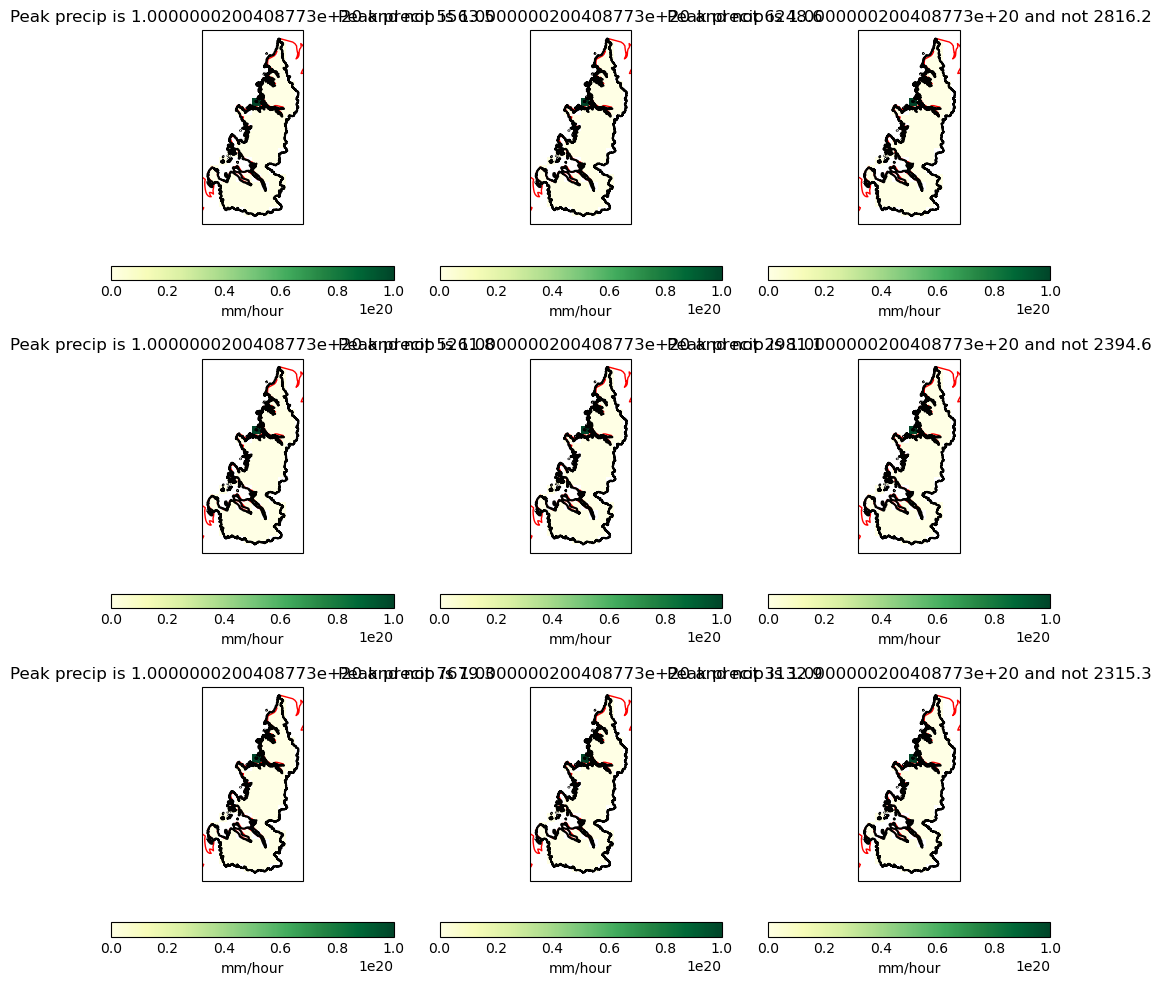

In [24]:
plot_n_peaks(rainfall_cube_dir_bc, ens_num = ens_num, catchment_num= catchment_num, bc=True)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
What happens if plot same plot using data that hasn't been bias corrected? 

</div>

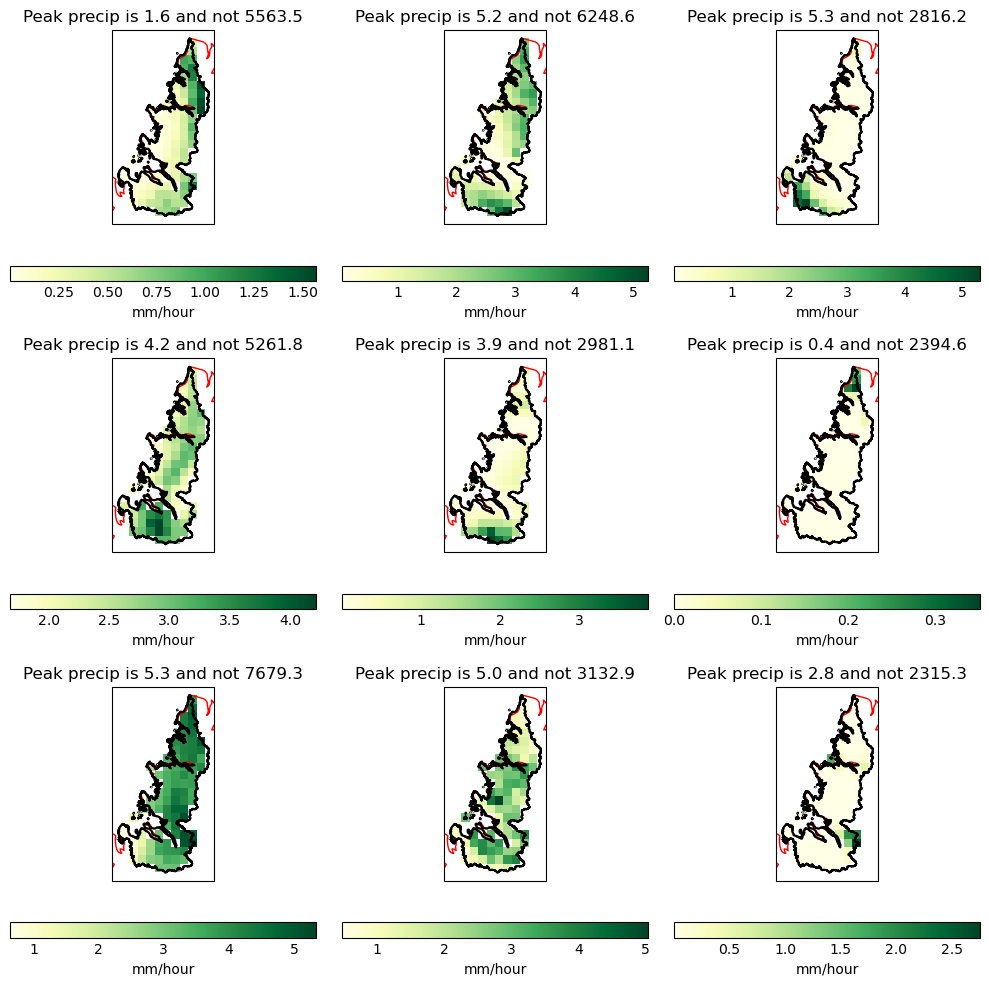

In [25]:
plot_n_peaks(rainfall_cube_dir_notbc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=False)